**Imports**

In [1]:
import pandas as pd
import tensorflow as tf
import numpy as np
from tensorflow.keras import layers
import matplotlib.pyplot as plt
from tensorflow.keras import regularizers
from sklearn.model_selection import train_test_split
import sys
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import classification_report
from sklearn.metrics import recall_score
from sklearn.metrics import precision_score
from sklearn.metrics import f1_score
from keras.optimizers import Adam
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.layers import GlobalAveragePooling2D


## Deliverable 1: Data Loading and Preprocessing

**Step 1.1: Load CSV file**

In [2]:
train_df = pd.read_csv("sign_mnist_train.csv")
test_df = pd.read_csv("sign_mnist_test.csv")

print(train_df.shape, test_df.shape)
train_df.head()

(27455, 785) (7172, 785)


,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,3,107,118,127,134,139,143,146,150,153,...,207,207,207,207,206,206,206,204,203,202
1,6,155,157,156,156,156,157,156,158,158,...,69,149,128,87,94,163,175,103,135,149
2,2,187,188,188,187,187,186,187,188,187,...,202,201,200,199,198,199,198,195,194,195
3,2,211,211,212,212,211,210,211,210,210,...,235,234,233,231,230,226,225,222,229,163
4,13,164,167,170,172,176,179,180,184,185,...,92,105,105,108,133,163,157,163,164,179


Had initial problems with setting up correct environment; checking to see if correct Python version is running (3.11 for tensor flow)

In [3]:
print(sys.executable)
print(sys.version)

/Users/fionac./nlpcv/tf-venv/bin/python
3.11.4 (v3.11.4:d2340ef257, Jun  6 2023, 19:15:51) [Clang 13.0.0 (clang-1300.0.29.30)]


In [4]:
# 24 classes (a-z excluding j&z)
num_classes = 24
# 28 by 28 pixels, one channel bc grayscale image
input_shape = (28, 28, 1)

#split train and test sets
y_train = train_df["label"].values
x_train = train_df.drop("label", axis=1).values

y_test = test_df["label"].values
x_test = test_df.drop("label", axis=1).values

**Step 1.2: Normalize pixel values to [0,1]**

In [5]:
x_train = x_train.astype("float32") / 255
x_test = x_test.astype("float32") / 255

#reshape 
x_train = x_train.reshape(-1, 28, 28)
x_test = x_test.reshape(-1, 28, 28)

#ensuring images have correct shape
x_train = np.expand_dims(x_train, -1)
x_test = np.expand_dims(x_test, -1)
print("x_train shape:", x_train.shape)
print(x_train.shape[0], "train samples")
print(x_test.shape[0], "test samples")

x_train shape: (27455, 28, 28, 1)
27455 train samples
7172 test samples


I displayed a few samples of the training dataset, in order to understand the features of the data I was working with.

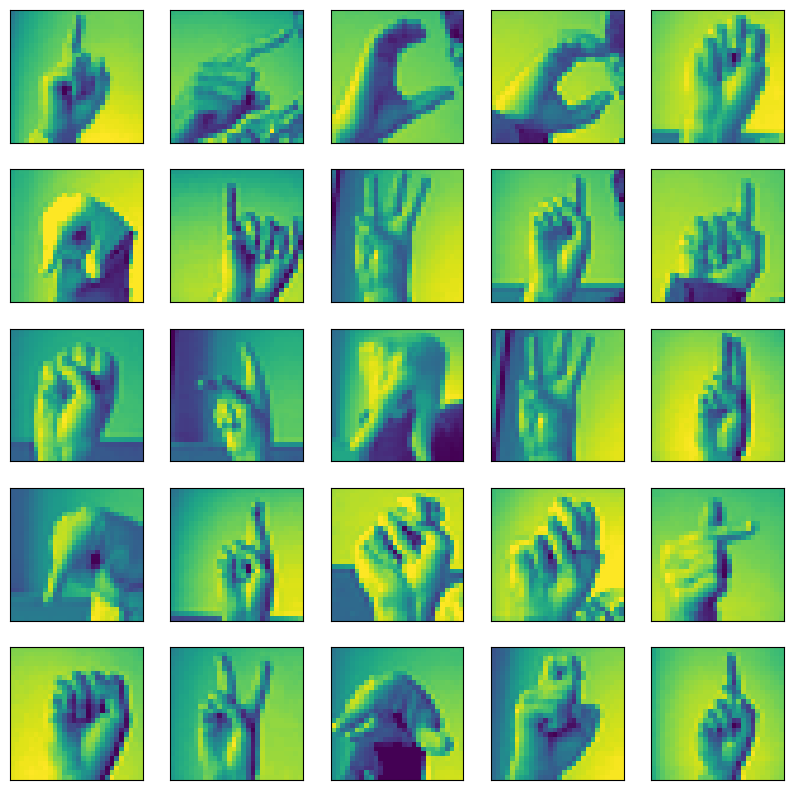

In [6]:
plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(np.squeeze(x_train[i,:,:,:]))
plt.show()

**Step 1.3: Creating validation split from train set**

AI Statement: 
I used AI for this particular step, when researching the best method to account for accurate labeling, despite two classes being skipped in the datatset (J and Z). I specficially used Chat GPT to explore the sklearn library, which has a label encoder import, designed for use cases like these. Even though the labels I was working with were already numbers, and didn't need categorgical transforming, I was running into an error where the label '24' was not in a valid range for the labeling options. This feature was able to remap the labels I was working with to be continous (0-23). By running .fit_transform on the training dataset the label encoder feature was able to build a new label mappung system, that could be applied to the testing and validations sets as well (Open AI, 2026).

In [7]:
# stratify with y_train to make sure class distribution matches original dataset
x_train, x_val, y_train, y_val = train_test_split(x_train, y_train, test_size=0.2, random_state=42, stratify=y_train)

# fixing issue with label allignments when printing confusion matrix and fitting model due to two classes being skipped
labe = LabelEncoder()
y_train = labe.fit_transform(y_train)
y_test = labe.transform(y_test)
y_val = labe.transform(y_val)
print("Train:", x_train.shape)
print("Val:", x_val.shape)
print("Test:", x_test.shape)

Train: (21964, 28, 28, 1)
Val: (5491, 28, 28, 1)
Test: (7172, 28, 28, 1)


## Deliverable 2: CNN Architectures

**Step 2.1: Baseline CNN architecture**

In [8]:
model_base = tf.keras.Sequential(
    [
        tf.keras.Input(shape=input_shape),
        layers.Conv2D(32, kernel_size=(3, 3), activation="relu"),
        layers.Conv2D(32, kernel_size=(3, 3), activation="relu"),
        layers.MaxPooling2D(pool_size=(2, 2)),
        layers.Flatten(),
        layers.Dense(num_classes, activation="softmax"),
    ]
)
model_base.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 24, 24, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 12, 12, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 24)             │       110,616 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 120,184 (469.47 KB)

 Trainable params: 120,184 (469.47 KB)

 Non-trainable params: 0 (0.00 B)

**Step 2.2: Enhanced CNN architecture - VGG-style Network**

In [9]:
model_vgg = tf.keras.Sequential(
    [
        # first block
        tf.keras.Input(shape=input_shape),
        layers.Conv2D(32, kernel_size=(3, 3), activation="relu", padding="same", kernel_regularizer=regularizers.l2(0.0001)),
        layers.BatchNormalization(),
        layers.Conv2D(32, kernel_size=(3, 3), activation="relu", padding="same", kernel_regularizer=regularizers.l2(0.0001)),
        layers.BatchNormalization(),
        layers.MaxPooling2D(pool_size=(2, 2)),
        layers.Dropout(0.25),

        # second block
        layers.Conv2D(64, kernel_size=(3, 3), activation="relu", padding="same", kernel_regularizer=regularizers.l2(0.0001)),
        layers.BatchNormalization(),
        layers.Conv2D(64, kernel_size=(3, 3), activation="relu", padding="same", kernel_regularizer=regularizers.l2(0.0001)),
        layers.BatchNormalization(),
        layers.MaxPooling2D(pool_size=(2, 2)),
        layers.Dropout(0.25),

        layers.GlobalAveragePooling2D(),
        layers.Dense(num_classes, activation="softmax"),
    ]
)
model_vgg.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 14, 14, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 24)             │         1,560 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 67,320 (262.97 KB)

 Trainable params: 66,936 (261.47 KB)

 Non-trainable params: 384 (1.50 KB)

**Step 2.3: Justify design choices**
- I chose to implement a VGG-style network to increase the depth of the model and enhance feature extraction. This type of neural network works especially well for classification based tasks, which aligns with goal of this model to correctly depict what letter in the ASL alphabet is presented in each image. This type of model also allowed me to explore various possibilites with the number of convolutional layers and other hyperparameters, which created a final model that was able to be fine tuned and flexible. 

## Deliverable 3: Training, Testing, and Evaluation

**Step 3.1: Hyperparameters**
- When creating the enhanced CNN architecture, in line with a VGG-style network, I started out with three convolutional blocks, followed by a fully connected layer at the end. The blocks each had two convolutional layers, followed by a max pooling layer in order to add more depth within the feature extraction before downsampling to the most relevant information. I started these blocks with 32 filters, then increased to 64 and 128 for the next blocks. With three blocks, I found that my model was not outperforming my baseline model. I decided to condense my model to two convolutional blocks, which alligned better with the size and simplicity of the dataset, and found this to improve my accuracy before adding in further tuning. I also ran different variations of the model starting the filter size at 16, rather than 32, but found the most optimal pattern to be doubling the size by two each time, beginning at 32. 
- For each convolutional layer, I applied the same hyperparameters. I used a kernel size of (3,3), as this was small enough to capture the details of the dataset. I thought back to our lecture and how we utilized the image of the matrix of squares sliding across the image, and referred back to past workshops where this was the baseline number we used for many models. The activation function used was "relu", which incorporates non-linearity, allowing the model to learn more complex patterns, and is an efficient choice for many neural networks. Next, I set padding to "same" which keeps the output size to be (28,28) so important spatial information isn't lost. Finally, I used L2 kernel regularization at the value (0.0001), to help avoid overfitting. I experimented with 0.001 and 0.0001, but found that a smaller learning rate drastically improved the accuracy for this model. After each convolutional layer I added a batch normalization layer that helped stabilize training by normalizing the output of each batch. I ended each block with a dropout layer of 0.3. Adding this hyperparameter made my accuracy increase by 3%, and is a large factor of controlling overfitting. In my model, this technique dropped 30% of neurons during training. This helps the model not memorize the data and learn more general patterns.
- When I first trained this model, I used a Flatten() layer at the end of the architecture to convert all of the relevant spatial feature from the max pooling layers into a 1D vector. However, this produced many parameters. To adjust this, I changed this line to GlobalAveragePooling2D(), which takes the feature maps and extracts a single value, instead of a whole vector. This reduced the parameter count drastically for my model, and also increased the accuracy to over 99%. 

**Step 3.1 (Hyperparameters continued):**
- The first hyperparameter I used for the VGGNet Model was to set the loss and optimizer values when compiling the model. I chose to use Adam because we have used it many times it class, as it is known to be a great optimizer for many different neural networks tasks. I experimented with trying SGD as an optimizer, but the accuracy drastically dropped, with the first epoch only having a 0.1% accuracy compared to 83% when using Adam.
- I also chose to implement the loss function to be be 'sparse_categorical_crossentropy', as it is well suited for multi-class classification tasks.
- I chose to use a batch size of 80, because I found that a smaller size led to a better test performance, despite running slightly slower. In this sense, I favored that the model produced better results, in a trade off for a longer runtime. I experimented with 64, 128, and 256, which were all baselines we used for many tasks in class. This model ran the best when finding an equillibrium between 64 and 128. 
- Later in the process, I used GlobalAveragePooling2D() instead of Flatten()

In [10]:
model_base.compile(
    loss='sparse_categorical_crossentropy',
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    metrics=['accuracy']
)

model_vgg.compile(
    loss='sparse_categorical_crossentropy',
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    metrics=['accuracy']
)

In [11]:
history_base = model_base.fit(x_train, y_train, batch_size=128, epochs=15, validation_data=(x_val, y_val))

Epoch 1/15
172/172 ━━━━━━━━━━━━━━━━━━━━ 7s 35ms/step - accuracy: 0.6463 - loss: 1.3304 - val_accuracy: 0.9372 - val_loss: 0.2753
Epoch 2/15
172/172 ━━━━━━━━━━━━━━━━━━━━ 5s 30ms/step - accuracy: 0.9828 - loss: 0.1103 - val_accuracy: 0.9998 - val_loss: 0.0345
Epoch 3/15
172/172 ━━━━━━━━━━━━━━━━━━━━ 5s 30ms/step - accuracy: 0.9999 - loss: 0.0186 - val_accuracy: 1.0000 - val_loss: 0.0103
Epoch 4/15
172/172 ━━━━━━━━━━━━━━━━━━━━ 5s 30ms/step - accuracy: 1.0000 - loss: 0.0070 - val_accuracy: 1.0000 - val_loss: 0.0050
Epoch 5/15
172/172 ━━━━━━━━━━━━━━━━━━━━ 5s 31ms/step - accuracy: 1.0000 - loss: 0.0037 - val_accuracy: 1.0000 - val_loss: 0.0030
Epoch 6/15
172/172 ━━━━━━━━━━━━━━━━━━━━ 5s 30ms/step - accuracy: 1.0000 - loss: 0.0023 - val_accuracy: 1.0000 - val_loss: 0.0020
Epoch 7/15
172/172 ━━━━━━━━━━━━━━━━━━━━ 5s 30ms/step - accuracy: 1.0000 - loss: 0.0015 - val_accuracy: 1.0000 - val_loss: 0.0014
Epoch 8/15
172/172 ━━━━━━━━━━━━━━━━━━━━ 5s 30ms/step - accuracy: 1.0000 - loss: 0.0011 - val_accu

In [12]:
score = model_base.evaluate(x_test, y_test, verbose=0)
print("Base model test loss:", score[0])
print("Base model test accuracy:", score[1])

Base model test loss: 0.9446857571601868
Base model test accuracy: 0.8558282256126404


**Step 3.1 (Hyperparameters continued):**
- Before fitting the model, I implemented an 'Early Stopping' regularization technique, to increase the efficiency of the model. With a patience parameter set to 4, the model will stop training if the validation loss continues to decrease after the span of 4 epochs. This helps prevent the model from overfitting, and also helps improve runtime. With an epoch number of 15 total, a patience of 5-7 epochs was a good baseline that I started with, but I found that if I wanted to value efficiency in runtime slightly more, I could decrease the patience while still maintaining the accuracy I attained at previously. 
- While fitting the model, I chose to set the epochs to 15, as I wanted to balance the tradeoff between the time it took to run and the accuracy. I experiemented with various epochs, first beginning at 100 epochs, which took over 20 minutes to run. As I began finetuning other hyperparameters, I decreased the epochs so I could try various metrics in my model without having to wait a long duration each time to see results. I ran many instances of the model at 20-25 epochs, but noticed that the accuracy was peaking towards the middle of the runtime, which allowed me to adjust the epochs down even further, saving computational power while still maintaining accuracy. 

In [13]:
early = EarlyStopping(
    monitor="val_loss",
    patience=4,
    restore_best_weights=True,
    verbose=1
)

history_vgg = model_vgg.fit(x_train, y_train, batch_size=128, epochs=15, validation_data=(x_val, y_val), callbacks=[early])

Epoch 1/15
172/172 ━━━━━━━━━━━━━━━━━━━━ 21s 110ms/step - accuracy: 0.5788 - loss: 1.7226 - val_accuracy: 0.0432 - val_loss: 3.7977
Epoch 2/15
172/172 ━━━━━━━━━━━━━━━━━━━━ 19s 110ms/step - accuracy: 0.9521 - loss: 0.4362 - val_accuracy: 0.0472 - val_loss: 4.0781
Epoch 3/15
172/172 ━━━━━━━━━━━━━━━━━━━━ 18s 106ms/step - accuracy: 0.9957 - loss: 0.1471 - val_accuracy: 0.1107 - val_loss: 4.3429
Epoch 4/15
172/172 ━━━━━━━━━━━━━━━━━━━━ 18s 106ms/step - accuracy: 0.9993 - loss: 0.0728 - val_accuracy: 0.9718 - val_loss: 0.1781
Epoch 5/15
172/172 ━━━━━━━━━━━━━━━━━━━━ 18s 106ms/step - accuracy: 0.9998 - loss: 0.0460 - val_accuracy: 1.0000 - val_loss: 0.0362
Epoch 6/15
172/172 ━━━━━━━━━━━━━━━━━━━━ 18s 107ms/step - accuracy: 1.0000 - loss: 0.0348 - val_accuracy: 1.0000 - val_loss: 0.0249
Epoch 7/15
172/172 ━━━━━━━━━━━━━━━━━━━━ 18s 107ms/step - accuracy: 1.0000 - loss: 0.0283 - val_accuracy: 1.0000 - val_loss: 0.0203
Epoch 8/15
172/172 ━━━━━━━━━━━━━━━━━━━━ 28s 165ms/step - accuracy: 1.0000 - loss: 0

In [14]:
score = model_vgg.evaluate(x_test, y_test, verbose=0)
print("VGG model test loss:", score[0])
print("VGG model test accuracy:", score[1])
# baseline model had test loss of 0.93 and test acc of 0.84
# new model had test loss of 1.23 and test acc of 0.88
# adding drop out helped so much! 0.94 accuracy and test loss of 0.33 (0.3 dropout)
# even better with 0.5 dropout! 0.96 acc and test loss of 0.18
# 0.97 acc with adding 0.0001 l2 regularization
# 0.973 acc and .136 test loss woith dropout of 0.3!

VGG model test loss: 0.023358384147286415
VGG model test accuracy: 0.9998605847358704


**Step 3.2: Accuracy, loss, runtime, and parameters**
- When running both the base model and VGGnet model, I noticed several differences and improvements between the runtimes. The base model ran much quicker, and only took around 1 minute 40 seconds to run. This is due to the model being much simpler, and not having many layers to parse through. However, the test accuracy was only around 84%, and the test loss was very high, around 1.43. When running the VGG net, the time to run increased to just around 6 minutes, but the test accuracy rose to around 96%, and the test loss dropped to 0.12. The accuracy and test loss tended to vary slightly between each run. The accuracy specfically can change around +-1%, based on the variability in samples of the dataset. 
- In regards to parameter counts, the baseline model had considerably fewer parameters due to its minimal layers in the model. It had a total of 120,184 parameters, and all of them were trainable. This means that all of them could be updated during training as the model learns. The VGGNet based model had 470,904 total parameters, with 640 that were not trainable. This means that 640 parameters were not updated during training. This was due to introducing batch normalization into my model as a regularization technique. Having some parameters that don't update allow the model to keep some of these learned features, like shapes and patterns in the images. This can help with overfitting as well, and let the model store information that helps it train more efficiently. 

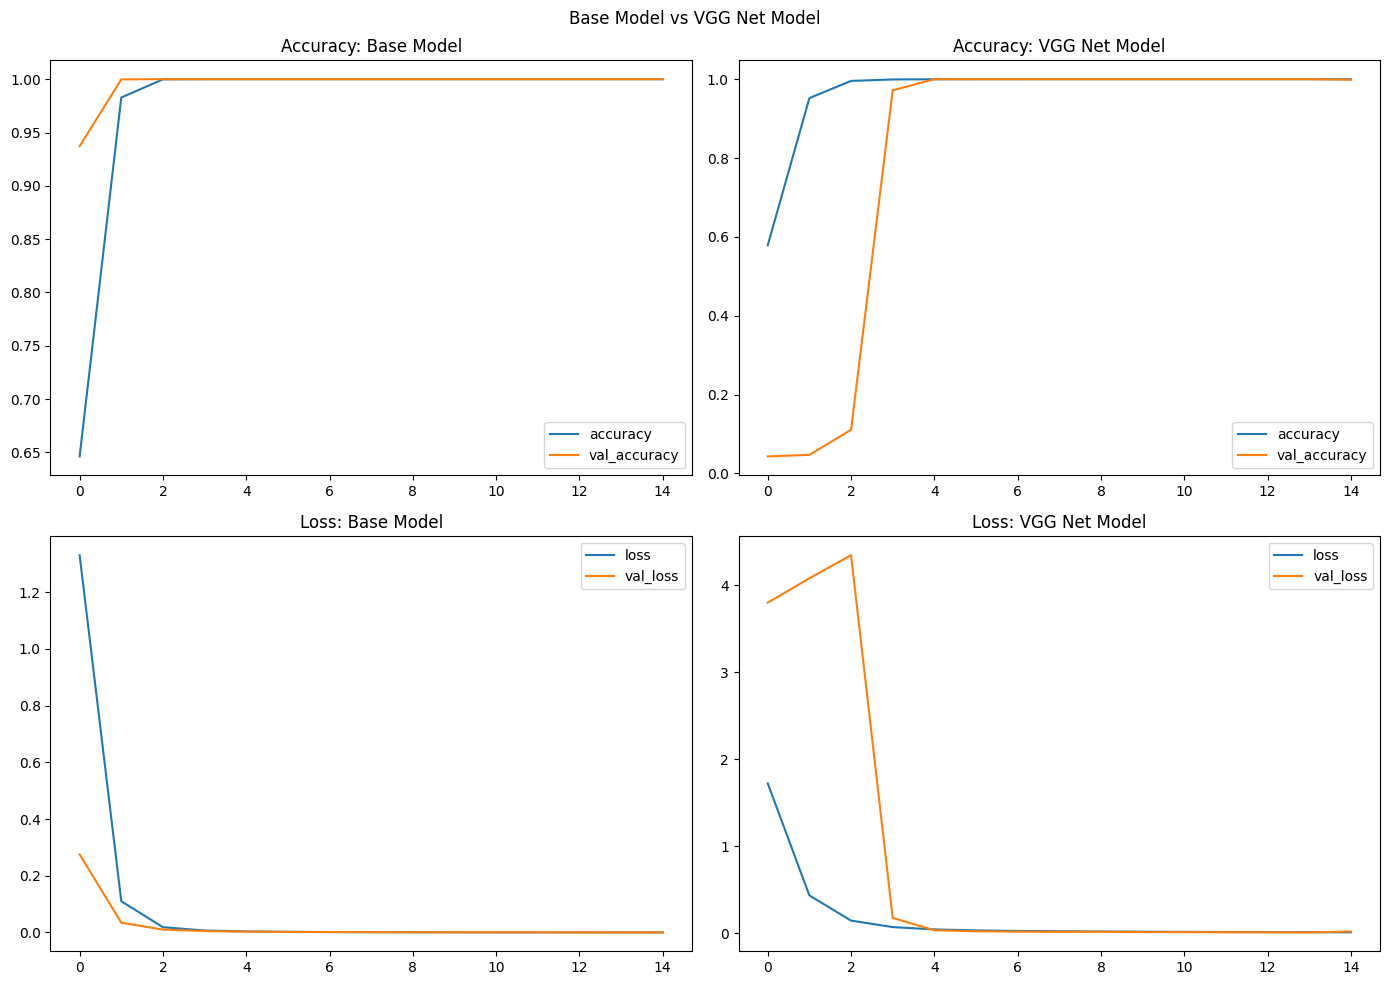

225/225 - 1s - 4ms/step - accuracy: 0.8558 - loss: 0.9447
225/225 - 2s - 8ms/step - accuracy: 0.9999 - loss: 0.0234


In [15]:
fig, ax = plt.subplots(2, 2, figsize=(14,10))
fig.suptitle("Base Model vs VGG Net Model")

ax[0,0].plot(history_base.history['accuracy'], label='accuracy')
ax[0,0].plot(history_base.history['val_accuracy'], label = 'val_accuracy')
ax[0,0].set_title('Accuracy: Base Model')
ax[0,0].legend(loc='lower right')

ax[0,1].plot(history_vgg.history['accuracy'], label='accuracy')
ax[0,1].plot(history_vgg.history['val_accuracy'], label = 'val_accuracy')
ax[0,1].set_title('Accuracy: VGG Net Model')
ax[0,1].legend(loc='lower right')

ax[1,0].plot(history_base.history['loss'], label='loss')
ax[1,0].plot(history_base.history['val_loss'], label = 'val_loss')
ax[1,0].set_title('Loss: Base Model')
ax[1,0].legend(loc='upper right')

ax[1,1].plot(history_vgg.history['loss'], label='loss')
ax[1,1].plot(history_vgg.history['val_loss'], label = 'val_loss')
ax[1,1].set_title('Loss: VGG Net Model')
ax[1,1].legend(loc='upper right')

plt.tight_layout()
plt.show()

test_loss, test_acc = model_base.evaluate(x_test,  y_test, verbose=2)
test_loss, test_acc = model_vgg.evaluate(x_test,  y_test, verbose=2)

In [16]:
y_pred_probs = model_vgg.predict(x_test)
# gives probs
y_pred_labels = np.argmax(y_pred_probs, axis=1)
# predicted class labels

225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step


**Step 3.3: Confusion Matrix**

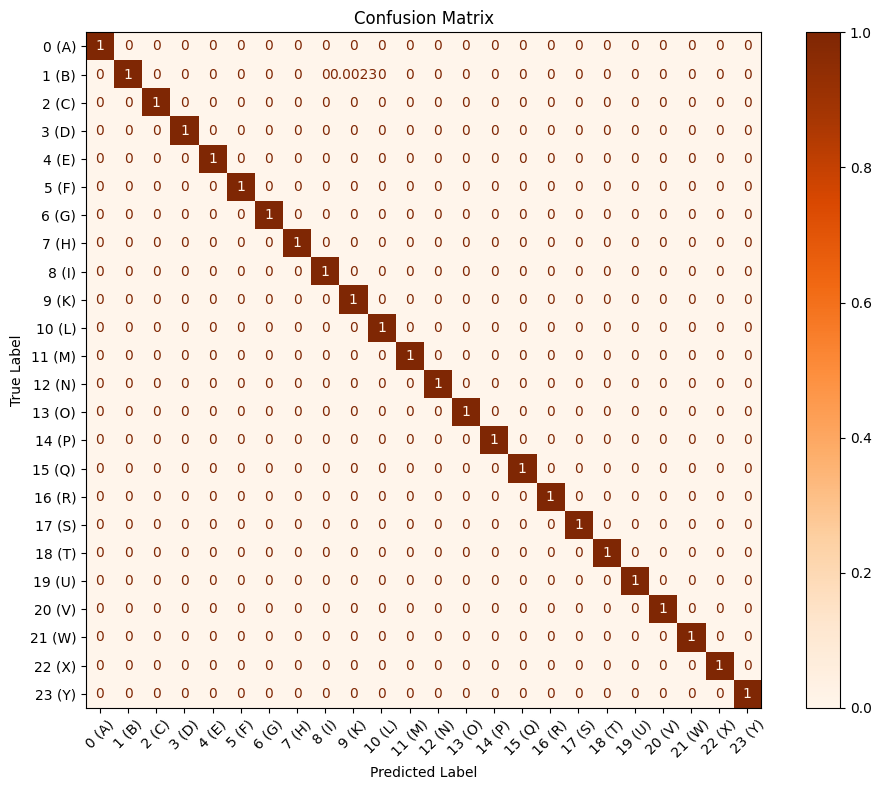

In [17]:
labels = np.unique(y_test)
letters = ['A','B','C','D','E','F','G','H','I','K','L','M','N','O','P','Q','R','S','T','U','V','W','X','Y']
disp_labels = [f"{i} ({letters[i]})" for i in labels]
cm = confusion_matrix(y_test, y_pred_labels, normalize="true")
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=disp_labels)
fig, ax = plt.subplots(figsize=(10,8))
disp.plot(cmap='Oranges', colorbar=True, ax=ax)
ax.set_title("Confusion Matrix")
ax.set_xlabel("Predicted Label")
ax.set_ylabel("True Label")
plt.setp(ax.get_xticklabels(), rotation=45)
plt.tight_layout()
plt.show()

**Step 3.4: Classification report and scores**

In [18]:
print("Confusion matrix:")
print(confusion_matrix(y_test, y_pred_labels))
print("\nClassification report:")
print(classification_report(y_test, y_pred_labels))

Confusion matrix:
[[331   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0]
 [  0 431   0   0   0   0   0   0   0   1   0   0   0   0   0   0   0   0
    0   0   0   0   0   0]
 [  0   0 310   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0]
 [  0   0   0 245   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0]
 [  0   0   0   0 498   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0]
 [  0   0   0   0   0 247   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0]
 [  0   0   0   0   0   0 348   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0]
 [  0   0   0   0   0   0   0 436   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0 288   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0 331   0   0   0   0   0   0   0   0

In [19]:
prec = precision_score(y_test, y_pred_labels, average="macro")
print("Precision score:", prec)
rec = recall_score(y_test, y_pred_labels, average="macro")
print("Recall score:", rec)
f1 = f1_score(y_test, y_pred_labels, average="macro")
print("F1 score:", f1)

Precision score: 0.9998744979919678
Recall score: 0.999903549382716
F1 score: 0.9998888731592706


**Step 3.4: Test images:**
- Lastly I displayed sample images from the test dataset, that compare the predicted label with the true label. All classes are classified accuratley. I ran the model multiple times, and each run showed each sample image to be identified correctly, reflecting the high precision and recall scores. 

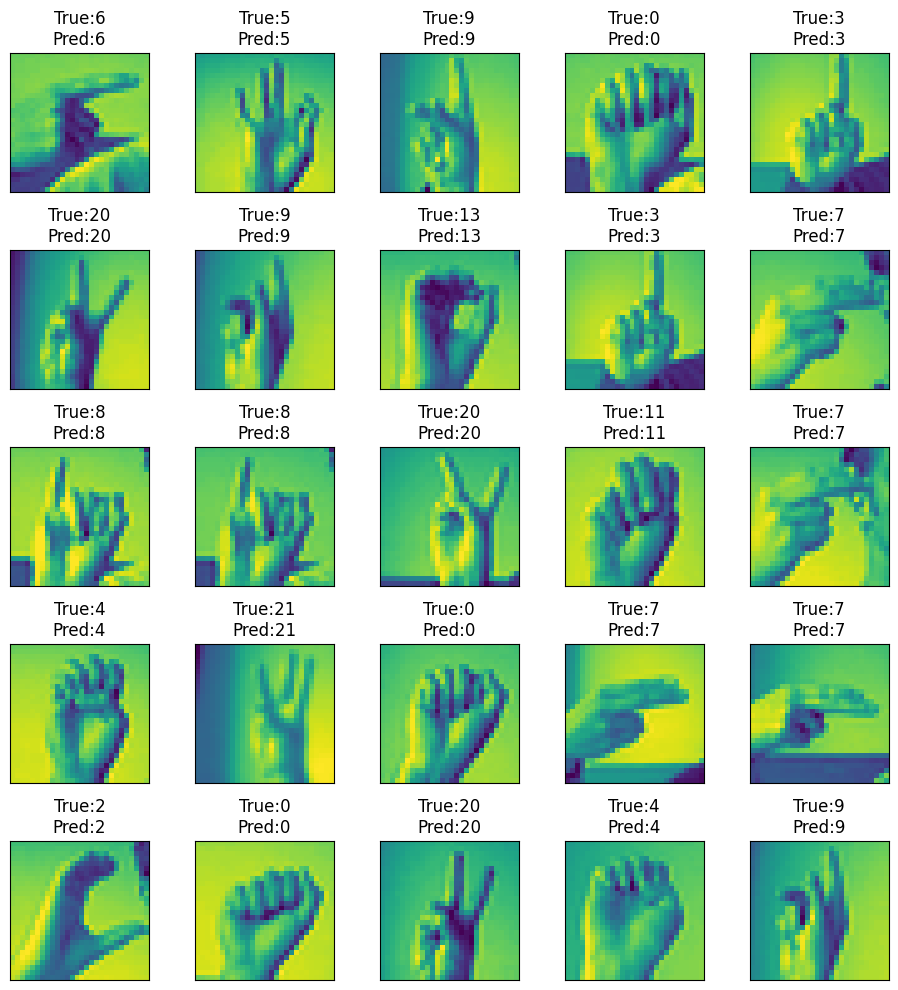

In [20]:
plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(np.squeeze(x_test[i,:,:,:]))
    plt.title(f"True:{y_test[i]}\nPred:{y_pred_labels[i]}")
    plt.tight_layout()
plt.show()

**Bibliography**

OpenAI (2026) ChatGPT (5.0). [Large Language Model]. Available from: https://chat.openai.com/ [Accessed 15 March 2026]